# Linear Regression for Profit Prediction

This notebook builds a linear regression model to predict movie **profit** based on:
- **Genres** (one-hot encoded)
- **Directors** (top directors as binary features)
- **Actors** (top actors as binary features)
- **isAdult** (binary)
- **Budget** (numerical)
- **Production Countries** (encoded)
- **Production Companies** (encoded)
- **Original Language** (encoded)

## Contents
1. Load Data and Explore
2. Data Preparation and Filtering
3. Feature Engineering (including Director & Actor merge)
4. Train-Test Split
5. Model Training
6. Model Evaluation
7. Visualize Predictions
8. Feature Importance Analysis (including Director & Actor impact)
9. Save Model

## 1. Load Data and Explore

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer
from scipy import stats
import joblib
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the combined dataset
df = pd.read_csv('../data/processed/imdb_tmdb_combined.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (30140, 26)

Columns: ['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult', 'startYear', 'endYear', 'runtimeMinutes', 'genres', 'averageRating', 'numVotes', 'tmdb_id', 'budget', 'revenue', 'tmdb_popularity', 'tmdb_vote_average', 'tmdb_vote_count', 'production_countries', 'production_companies', 'spoken_languages', 'original_language', 'tagline', 'roi', 'profit', 'has_budget_data', 'has_revenue_data']

First few rows:


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes,tmdb_id,budget,revenue,tmdb_popularity,tmdb_vote_average,tmdb_vote_count,production_countries,production_companies,spoken_languages,original_language,tagline,roi,profit,has_budget_data,has_revenue_data
0,tt0111161,movie,The Shawshank Redemption,The Shawshank Redemption,0.000,1994.000,NaN,142.000,Drama,9.300,3103987,278.000,25000000.000,28341469.000,29.450,8.712,28979.000,US,Castle Rock Entertainment,en,en,Fear can hold you prisoner. Hope can set you f...,13.366,3341469.000,True,True
1,tt0468569,movie,The Dark Knight,The Dark Knight,0.000,2008.000,NaN,152.000,"Action,Crime,Drama",9.100,3079053,155.000,185000000.000,1004558444.000,29.797,8.523,34497.000,"GB,US","Warner Bros. Pictures,Legendary Pictures,Synco...","en,zh",en,Welcome to a world without rules.,443.005,819558444.000,True,True
2,tt1375666,movie,Inception,Inception,0.000,2010.000,NaN,148.000,"Action,Adventure,Sci-Fi",8.800,2734473,27205.000,160000000.000,839030630.000,24.544,8.370,38040.000,"GB,US","Legendary Pictures,Syncopy,Warner Bros. Pictures","en,fr,ja,sw",en,Your mind is the scene of the crime.,424.394,679030630.000,True,True
3,tt0137523,movie,Fight Club,Fight Club,0.000,1999.000,NaN,139.000,"Crime,Drama,Thriller",8.800,2519445,550.000,63000000.000,100853753.000,23.648,8.437,30842.000,"DE,US","Fox 2000 Pictures,Regency Enterprises,Linson E...",en,en,Mischief. Mayhem. Soap.,60.085,37853753.000,True,True
4,tt0109830,movie,Forrest Gump,Forrest Gump,0.000,1994.000,NaN,142.000,"Drama,Romance",8.800,2423611,13.000,55000000.000,677387716.000,18.610,8.500,28697.000,US,"Paramount Pictures,The Steve Tisch Company,Wen...",en,en,The world will never be the same once you've s...,1131.614,622387716.000,True,True


In [3]:
# Check data types and missing values
print("Data Info:")
print("="*80)
df.info()

print("\n" + "="*80)
print("Missing Values:")
print("="*80)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    for col, count in missing.items():
        print(f"{col:30s}: {count:6d} ({count/len(df)*100:5.1f}%)")
else:
    print("No missing values!")

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30140 entries, 0 to 30139
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tconst                30140 non-null  object 
 1   titleType             30140 non-null  object 
 2   primaryTitle          30140 non-null  object 
 3   originalTitle         30140 non-null  object 
 4   isAdult               30140 non-null  float64
 5   startYear             30140 non-null  float64
 6   endYear               0 non-null      float64
 7   runtimeMinutes        30140 non-null  float64
 8   genres                30130 non-null  object 
 9   averageRating         30140 non-null  float64
 10  numVotes              30140 non-null  int64  
 11  tmdb_id               999 non-null    float64
 12  budget                999 non-null    float64
 13  revenue               999 non-null    float64
 14  tmdb_popularity       999 non-null    float64
 15  tmdb_vot

## 2. Data Preparation and Filtering

In [4]:
# Filter for movies with complete financial data
print("Financial Data Coverage:")
print("="*80)
print(f"Total movies: {len(df):,}")
print(f"With budget data: {(df['budget'] > 0).sum():,} ({(df['budget'] > 0).sum()/len(df)*100:.1f}%)")
print(f"With revenue data: {(df['revenue'] > 0).sum():,} ({(df['revenue'] > 0).sum()/len(df)*100:.1f}%)")
print(f"With both budget and revenue: {((df['budget'] > 0) & (df['revenue'] > 0)).sum():,}")

# Filter for movies with complete financial data
df_financial = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()
print(f"\n✓ Filtered dataset: {len(df_financial):,} movies with complete financial data")

# Calculate profit if not already present
if 'profit' not in df_financial.columns:
    df_financial['profit'] = df_financial['revenue'] - df_financial['budget']
    print("✓ Calculated profit column")

Financial Data Coverage:
Total movies: 30,140
With budget data: 996 (3.3%)
With revenue data: 990 (3.3%)
With both budget and revenue: 989

✓ Filtered dataset: 989 movies with complete financial data


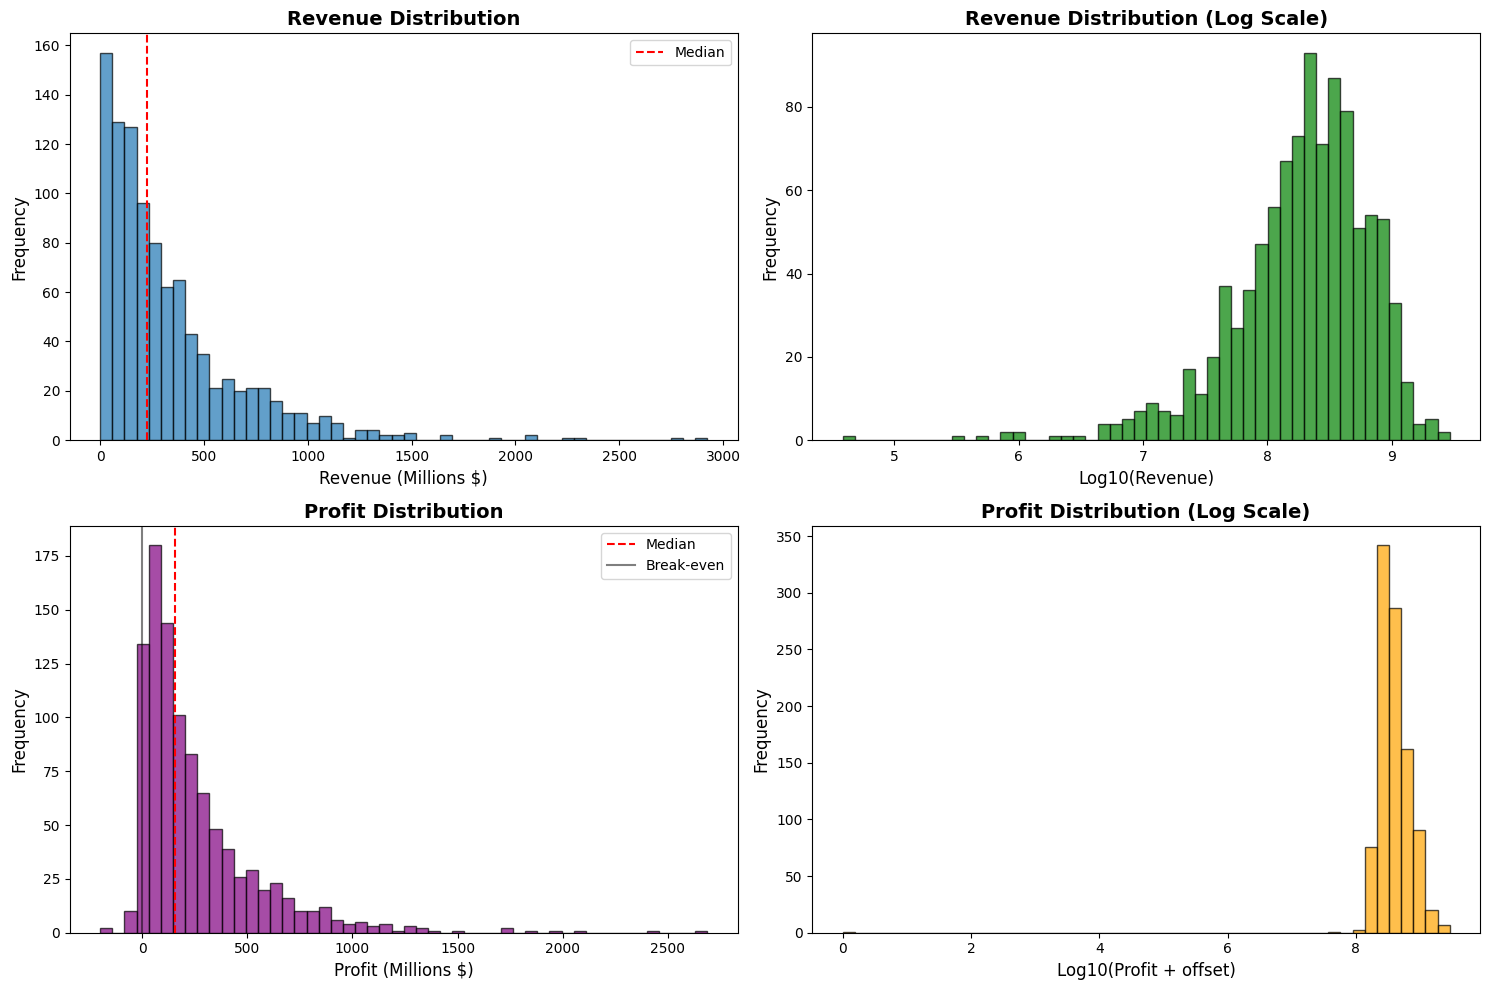


Revenue Statistics:
  Mean: $333,207,104
  Median: $225,253,184
  Min: $38,256
  Max: $2,923,706,026

Profit Statistics:
  Mean: $257,751,837
  Median: $158,300,000
  Min: $-199,545,977
  Max: $2,686,706,026
  Movies with profit > 0: 956 (96.7%)


In [5]:
# Explore target variables (revenue and profit)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Revenue distribution
axes[0, 0].hist(df_financial['revenue'] / 1e6, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Revenue (Millions $)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Revenue Distribution', fontsize=14, fontweight='bold')
axes[0, 0].axvline(df_financial['revenue'].median() / 1e6, color='red', linestyle='--', label='Median')
axes[0, 0].legend()

# Log-scaled revenue distribution
axes[0, 1].hist(np.log10(df_financial['revenue'] + 1), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Log10(Revenue)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Revenue Distribution (Log Scale)', fontsize=14, fontweight='bold')

# Profit distribution
axes[1, 0].hist(df_financial['profit'] / 1e6, bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].set_xlabel('Profit (Millions $)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Profit Distribution', fontsize=14, fontweight='bold')
axes[1, 0].axvline(df_financial['profit'].median() / 1e6, color='red', linestyle='--', label='Median')
axes[1, 0].axvline(0, color='black', linestyle='-', alpha=0.5, label='Break-even')
axes[1, 0].legend()

# Log-scaled profit distribution
# Handle negative profits by adding offset
profit_offset = abs(df_financial['profit'].min()) + 1 if df_financial['profit'].min() < 0 else 1
axes[1, 1].hist(np.log10(df_financial['profit'] + profit_offset), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Log10(Profit + offset)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Profit Distribution (Log Scale)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
print("\nRevenue Statistics:")
print(f"  Mean: ${df_financial['revenue'].mean():,.0f}")
print(f"  Median: ${df_financial['revenue'].median():,.0f}")
print(f"  Min: ${df_financial['revenue'].min():,.0f}")
print(f"  Max: ${df_financial['revenue'].max():,.0f}")

print("\nProfit Statistics:")
print(f"  Mean: ${df_financial['profit'].mean():,.0f}")
print(f"  Median: ${df_financial['profit'].median():,.0f}")
print(f"  Min: ${df_financial['profit'].min():,.0f}")
print(f"  Max: ${df_financial['profit'].max():,.0f}")
print(f"  Movies with profit > 0: {(df_financial['profit'] > 0).sum():,} ({(df_financial['profit'] > 0).sum()/len(df_financial)*100:.1f}%)")

## 3. Feature Engineering

We'll encode the following features:
- **Genres**: One-hot encoding (multi-label)
- **Directors**: Binary features from processed_movie_features.csv
- **Actors**: Binary features from processed_movie_features.csv
- **isAdult**: Already binary
- **Budget**: Use as-is (numerical)
- **Production Countries**: One-hot encoding or top N
- **Production Companies**: One-hot encoding or top N
- **Original Language**: One-hot encoding

In [6]:
# Create a copy for feature engineering
df_features = df_financial.copy()

# 1. Process Genres (multi-label one-hot encoding)
print("Processing Genres...")
# Split genres by comma and create list
df_features['genres_list'] = df_features['genres'].fillna('').str.split(',')

# Get all unique genres
all_genres = set()
for genres in df_features['genres_list']:
    all_genres.update([g.strip() for g in genres if g.strip()])
all_genres = sorted(all_genres)
print(f"  Found {len(all_genres)} unique genres: {all_genres}")

# Create binary columns for each genre
for genre in all_genres:
    df_features[f'genre_{genre}'] = df_features['genres_list'].apply(
        lambda x: 1 if genre in [g.strip() for g in x] else 0
    )
print(f"✓ Created {len(all_genres)} genre features")

Processing Genres...
  Found 21 unique genres: ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western']
✓ Created 21 genre features


In [7]:
# 2. Process isAdult (already binary, just ensure it's numeric)
print("Processing isAdult...")
df_features['isAdult'] = df_features['isAdult'].fillna(0).astype(int)
print(f"✓ isAdult feature ready")
print(f"  Adult movies: {df_features['isAdult'].sum()} ({df_features['isAdult'].sum()/len(df_features)*100:.1f}%)")

Processing isAdult...
✓ isAdult feature ready
  Adult movies: 0 (0.0%)


In [8]:
# 3. Process Production Countries (top N approach)
print("Processing Production Countries...")
# Split production countries
df_features['prod_countries_list'] = df_features['production_countries'].fillna('').str.split(',')

# Count country occurrences
country_counts = {}
for countries in df_features['prod_countries_list']:
    for country in countries:
        country = country.strip()
        if country:
            country_counts[country] = country_counts.get(country, 0) + 1

# Get top 20 countries
top_countries = sorted(country_counts.items(), key=lambda x: x[1], reverse=True)[:20]
top_country_names = [c[0] for c in top_countries]
print(f"  Top 20 countries: {top_country_names}")

# Create binary features for top countries
for country in top_country_names:
    df_features[f'country_{country}'] = df_features['prod_countries_list'].apply(
        lambda x: 1 if country in [c.strip() for c in x] else 0
    )
print(f"✓ Created {len(top_country_names)} country features")

Processing Production Countries...
  Top 20 countries: ['US', 'GB', 'DE', 'FR', 'CA', 'AU', 'ES', 'JP', 'IT', 'CN', 'NZ', 'IN', 'HK', 'MX', 'IE', 'KR', 'BR', 'ZA', 'CH', 'BG']
✓ Created 20 country features


In [9]:
# 4. Process Production Companies (top N approach)
print("Processing Production Companies...")
# Split production companies
df_features['prod_companies_list'] = df_features['production_companies'].fillna('').str.split(',')

# Count company occurrences
company_counts = {}
for companies in df_features['prod_companies_list']:
    for company in companies:
        company = company.strip()
        if company:
            company_counts[company] = company_counts.get(company, 0) + 1

# Get top 30 companies
top_companies = sorted(company_counts.items(), key=lambda x: x[1], reverse=True)[:30]
top_company_names = [c[0] for c in top_companies]
print(f"  Top 30 companies: {top_company_names[:10]}... (showing first 10)")

# Create binary features for top companies
for company in top_company_names:
    # Clean company name for column name
    clean_name = company.replace(' ', '_').replace('.', '').replace(',', '')[:30]
    df_features[f'company_{clean_name}'] = df_features['prod_companies_list'].apply(
        lambda x: 1 if company in [c.strip() for c in x] else 0
    )
print(f"✓ Created {len(top_company_names)} company features")

Processing Production Companies...
  Top 30 companies: ['Warner Bros. Pictures', 'Universal Pictures', 'Columbia Pictures', '20th Century Fox', 'Paramount Pictures', 'New Line Cinema', 'Marvel Studios', 'DreamWorks Pictures', 'Relativity Media', 'Village Roadshow Pictures']... (showing first 10)
✓ Created 30 company features


In [10]:
# 5. Process Original Language (top N approach)
print("Processing Original Language...")
# Get language distribution
lang_counts = df_features['original_language'].value_counts()
print(f"  Total unique languages: {len(lang_counts)}")
print(f"  Top 10 languages:\n{lang_counts.head(10)}")

# Get top 15 languages
top_languages = lang_counts.head(15).index.tolist()
print(f"\n  Using top 15 languages: {top_languages}")

# Create binary features for top languages
for lang in top_languages:
    df_features[f'lang_{lang}'] = (df_features['original_language'] == lang).astype(int)
print(f"✓ Created {len(top_languages)} language features")

Processing Original Language...
  Total unique languages: 12
  Top 10 languages:
original_language
en    956
ja      6
it      6
fr      5
ko      5
es      3
de      3
pt      1
hi      1
da      1
Name: count, dtype: int64

  Using top 15 languages: ['en', 'ja', 'it', 'fr', 'ko', 'es', 'de', 'pt', 'hi', 'da', 'zh', 'fa']
✓ Created 12 language features


In [11]:
# 6. Budget feature (use as-is, but handle scale)
print("Processing Budget...")
df_features['budget_millions'] = df_features['budget'] / 1e6
print(f"✓ Created budget_millions feature")
print(f"  Budget range: ${df_features['budget'].min():,.0f} - ${df_features['budget'].max():,.0f}")
print(f"  Budget (millions) range: ${df_features['budget_millions'].min():.2f}M - ${df_features['budget_millions'].max():.2f}M")

Processing Budget...
✓ Created budget_millions feature
  Budget range: $15,000 - $416,000,000
  Budget (millions) range: $0.01M - $416.00M


In [12]:
# 7. Additional features from existing data
print("Processing Additional Features...")

# Runtime (if available)
if 'runtimeMinutes' in df_features.columns:
    df_features['runtime'] = pd.to_numeric(df_features['runtimeMinutes'], errors='coerce').fillna(0)
    print(f"✓ Created runtime feature")

# Start year (as numerical)
if 'startYear' in df_features.columns:
    df_features['year'] = pd.to_numeric(df_features['startYear'], errors='coerce').fillna(2000)
    print(f"✓ Created year feature")

# Genre count (number of genres)
df_features['genre_count'] = df_features['genres_list'].apply(len)
print(f"✓ Created genre_count feature")

# Country count
df_features['country_count'] = df_features['prod_countries_list'].apply(len)
print(f"✓ Created country_count feature")

# Company count
df_features['company_count'] = df_features['prod_companies_list'].apply(len)
print(f"✓ Created company_count feature")

Processing Additional Features...
✓ Created runtime feature
✓ Created year feature
✓ Created genre_count feature
✓ Created country_count feature
✓ Created company_count feature


In [13]:
# 8. Load and merge director/actor features from processed_movie_features.csv
print("Loading Director and Actor Features...")

# Load the processed features file
features_with_people = pd.read_csv('../data/processed_movie_features.csv')

# Get director and actor columns
director_cols = [col for col in features_with_people.columns if col.startswith('director_') and col.startswith('director_nm')]
actor_cols = [col for col in features_with_people.columns if col.startswith('actor_') and col.startswith('actor_nm')]

print(f"  Found {len(director_cols)} director features")
print(f"  Found {len(actor_cols)} actor features")

# Merge with our current dataset using tconst as key
# Select only tconst and director/actor columns
people_features = features_with_people[['tconst'] + director_cols + actor_cols]

# Merge with df_features
print(f"  Before merge: {df_features.shape}")
df_features = df_features.merge(people_features, on='tconst', how='left')
print(f"  After merge: {df_features.shape}")

# Fill any NaN values in director/actor columns with 0
for col in director_cols + actor_cols:
    df_features[col] = df_features[col].fillna(0).astype(int)

print(f"✓ Merged {len(director_cols)} director and {len(actor_cols)} actor features")

# Load people mapping for better readability later
with open('../data/top_people_mapping.json', 'r') as f:
    people_mapping = json.load(f)
    print(f"✓ Loaded people mapping with {len(people_mapping.get('directors', {}))} directors and {len(people_mapping.get('actors', {}))} actors")

Loading Director and Actor Features...
  Found 10 director features
  Found 20 actor features
  Before merge: (989, 118)
  After merge: (1004, 148)
✓ Merged 10 director and 20 actor features
✓ Loaded people mapping with 20 directors and 20 actors
  Found 10 director features
  Found 20 actor features
  Before merge: (989, 118)
  After merge: (1004, 148)
✓ Merged 10 director and 20 actor features
✓ Loaded people mapping with 20 directors and 20 actors


### 8a. Fix Director/Actor Features

The previous director/actor features were selected from the full IMDb dataset, but we need features from people who actually appear in movies with financial data. Let's create new features based only on the directors/actors in our filtered dataset.

In [14]:
# Load title.crew data to get directors for movies with financial data
print("Loading IMDb crew data...")
import gzip

# Load title.crew to get directors and writers
crew_data = pd.read_csv('../data/raw/title.crew.tsv.gz', 
                        sep='\t', 
                        compression='gzip')
print(f"✓ Loaded crew data: {len(crew_data):,} titles")

# Filter to only movies in our financial dataset
financial_tconsts = set(df_financial['tconst'])
crew_financial = crew_data[crew_data['tconst'].isin(financial_tconsts)].copy()
print(f"✓ Filtered to {len(crew_financial):,} movies with financial data")

# Extract director IDs
all_directors = []
for directors_str in crew_financial['directors'].dropna():
    if directors_str != '\\N':
        directors = directors_str.split(',')
        all_directors.extend(directors)

# Count director occurrences
from collections import Counter
director_counts = Counter(all_directors)
print(f"✓ Found {len(director_counts)} unique directors")

# Get top 50 directors by movie count
top_directors = [d for d, count in director_counts.most_common(50)]
print(f"✓ Selected top 50 directors")
print(f"  Example: {top_directors[:5]}")

Loading IMDb crew data...
✓ Loaded crew data: 11,942,630 titles
✓ Filtered to 989 movies with financial data
✓ Found 488 unique directors
✓ Selected top 50 directors
  Example: ['nm0000229', 'nm0000631', 'nm0000217', 'nm0000318', 'nm0000233']
✓ Loaded crew data: 11,942,630 titles
✓ Filtered to 989 movies with financial data
✓ Found 488 unique directors
✓ Selected top 50 directors
  Example: ['nm0000229', 'nm0000631', 'nm0000217', 'nm0000318', 'nm0000233']


In [15]:
# Load title.principals to get actors for movies with financial data
print("Loading IMDb principals data...")

# Load title.principals to get actors
principals_data = pd.read_csv('../data/raw/title.principals.tsv.gz', 
                              sep='\t', 
                              compression='gzip',
                              usecols=['tconst', 'ordering', 'nconst', 'category'])
print(f"✓ Loaded principals data: {len(principals_data):,} records")

# Filter to only movies in our financial dataset and actors/actresses
principals_financial = principals_data[
    (principals_data['tconst'].isin(financial_tconsts)) &
    (principals_data['category'].isin(['actor', 'actress']))
].copy()
print(f"✓ Filtered to {len(principals_financial):,} actor records")

# Count actor occurrences
actor_counts = principals_financial['nconst'].value_counts()
print(f"✓ Found {len(actor_counts)} unique actors")

# Get top 50 actors by movie count
top_actors = actor_counts.head(50).index.tolist()
print(f"✓ Selected top 50 actors")
print(f"  Example: {top_actors[:5]}")

Loading IMDb principals data...
✓ Loaded principals data: 95,006,895 records
✓ Loaded principals data: 95,006,895 records
✓ Filtered to 10,399 actor records
✓ Found 5472 unique actors
✓ Selected top 50 actors
  Example: ['nm0000168', 'nm0000093', 'nm0000158', 'nm0424060', 'nm0413168']
✓ Filtered to 10,399 actor records
✓ Found 5472 unique actors
✓ Selected top 50 actors
  Example: ['nm0000168', 'nm0000093', 'nm0000158', 'nm0424060', 'nm0413168']


In [16]:
# Create binary features for top directors
print("Creating director binary features...")

for director_id in top_directors:
    col_name = f'director_{director_id}'
    # Check if this director directed each movie
    df_features[col_name] = df_features['tconst'].apply(
        lambda tconst: 1 if tconst in crew_financial[
            crew_financial['directors'].fillna('').str.contains(director_id, regex=False)
        ]['tconst'].values else 0
    )

print(f"✓ Created {len(top_directors)} director binary features")

# Create binary features for top actors
print("Creating actor binary features...")

for actor_id in top_actors:
    col_name = f'actor_{actor_id}'
    # Check if this actor appeared in each movie
    df_features[col_name] = df_features['tconst'].apply(
        lambda tconst: 1 if tconst in principals_financial[
            principals_financial['nconst'] == actor_id
        ]['tconst'].values else 0
    )

print(f"✓ Created {len(top_actors)} actor binary features")

# Store new column names
new_director_cols = [f'director_{d}' for d in top_directors]
new_actor_cols = [f'actor_{a}' for a in top_actors]

# Verify features
print(f"\nFeature Verification:")
print(f"  Total director features: {len(new_director_cols)}")
print(f"  Total actor features: {len(new_actor_cols)}")
print(f"  Directors with >0 movies: {sum([df_features[col].sum() > 0 for col in new_director_cols])}")
print(f"  Actors with >0 movies: {sum([df_features[col].sum() > 0 for col in new_actor_cols])}")

Creating director binary features...
✓ Created 50 director binary features
Creating actor binary features...
✓ Created 50 director binary features
Creating actor binary features...
✓ Created 50 actor binary features

Feature Verification:
  Total director features: 50
  Total actor features: 50
  Directors with >0 movies: 50
  Actors with >0 movies: 50
✓ Created 50 actor binary features

Feature Verification:
  Total director features: 50
  Total actor features: 50
  Directors with >0 movies: 50
  Actors with >0 movies: 50


In [18]:
# Create feature_columns list with new director/actor features
print("Creating feature columns list with new director/actor features...")

# Collect all feature columns
feature_columns = []

# Genre features
feature_columns.extend([f'genre_{g}' for g in all_genres])

# isAdult
feature_columns.append('isAdult')

# Budget
feature_columns.append('budget_millions')

# Country features
feature_columns.extend([f'country_{c}' for c in top_country_names])

# Company features
feature_columns.extend([f'company_{c.replace(" ", "_").replace(".", "").replace(",", "")[:30]}' for c in top_company_names])

# Language features
feature_columns.extend([f'lang_{l}' for l in top_languages])

# NEW: Director and Actor features (from financial data subset)
feature_columns.extend(new_director_cols)
feature_columns.extend(new_actor_cols)

# Additional features
if 'runtime' in df_features.columns:
    feature_columns.append('runtime')
if 'year' in df_features.columns:
    feature_columns.append('year')
feature_columns.extend(['genre_count', 'country_count', 'company_count'])

print(f"\n📊 Total Features: {len(feature_columns)}")
print(f"\nFeature Breakdown:")
print(f"  - Genres: {len([c for c in feature_columns if c.startswith('genre_') and not c == 'genre_count'])}")
print(f"  - Directors: {len(new_director_cols)}")
print(f"  - Actors: {len(new_actor_cols)}")
print(f"  - Countries: {len([c for c in feature_columns if c.startswith('country_')])}")
print(f"  - Companies: {len([c for c in feature_columns if c.startswith('company_')])}")
print(f"  - Languages: {len([c for c in feature_columns if c.startswith('lang_')])}")
print(f"  - Other: {len([c for c in feature_columns if not any(c.startswith(p) for p in ['genre_', 'country_', 'company_', 'lang_', 'director_', 'actor_'])])}")

print("\n✓ Ready to train profit prediction model with new director/actor features!")

Creating feature columns list with new director/actor features...

📊 Total Features: 190

Feature Breakdown:
  - Genres: 21
  - Directors: 50
  - Actors: 50
  - Countries: 21
  - Companies: 31
  - Languages: 12
  - Other: 4

✓ Ready to train profit prediction model with new director/actor features!


## 4. Train-Test Split

In [19]:
# Prepare feature matrix X
X = df_features[feature_columns]

# Prepare target variable
y_profit = df_features['profit']

# Check for any missing values
print(f"Missing values in X: {X.isna().sum().sum()}")
print(f"Missing values in y_profit: {y_profit.isna().sum()}")

# Fill any remaining missing values
X = X.fillna(0)

print(f"\n✓ Feature matrix shape: {X.shape}")
print(f"✓ Target variable prepared")

Missing values in X: 0
Missing values in y_profit: 0

✓ Feature matrix shape: (1004, 190)
✓ Target variable prepared


In [20]:
# Split data into train and test sets (80/20 split)
X_train, X_test, y_profit_train, y_profit_test = train_test_split(
    X, y_profit, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train):,}")
print(f"Test set size: {len(X_test):,}")

print(f"\nProfit Target Statistics:")
print(f"  Train - Mean: ${y_profit_train.mean():,.0f}, Std: ${y_profit_train.std():,.0f}")
print(f"  Test  - Mean: ${y_profit_test.mean():,.0f}, Std: ${y_profit_test.std():,.0f}")

Training set size: 803
Test set size: 201

Profit Target Statistics:
  Train - Mean: $262,476,141, Std: $300,225,322
  Test  - Mean: $252,164,904, Std: $305,142,995


## 5. Model Training

In [21]:
# Train Profit Prediction Model
print("Training Profit Prediction Model...")
import time
start_time = time.time()

profit_model = LinearRegression()
profit_model.fit(X_train, y_profit_train)

training_time_profit = time.time() - start_time
print(f"✓ Profit model training completed in {training_time_profit:.2f} seconds")

# Make predictions
y_profit_train_pred = profit_model.predict(X_train)
y_profit_test_pred = profit_model.predict(X_test)
print("✓ Profit predictions generated")

Training Profit Prediction Model...
✓ Profit model training completed in 0.04 seconds
✓ Profit predictions generated


## 6. Model Evaluation

In [22]:
# Evaluation function
def evaluate_model(y_true, y_pred, model_name, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Calculate MAPE (Mean Absolute Percentage Error)
    # Avoid division by zero
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100
    
    print(f"\n{model_name} - {dataset_name} Set:")
    print(f"{'='*60}")
    print(f"RMSE:  ${rmse:,.0f}")
    print(f"MAE:   ${mae:,.0f}")
    print(f"R²:    {r2:.4f}")
    print(f"MAPE:  {mape:.2f}%")
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}

In [23]:
# Evaluate Profit Model
print("\n" + "="*70)
print(" PROFIT PREDICTION MODEL EVALUATION")
print("="*70)

profit_train_metrics = evaluate_model(y_profit_train, y_profit_train_pred, "Profit Model", "Training")
profit_test_metrics = evaluate_model(y_profit_test, y_profit_test_pred, "Profit Model", "Test")

# Check for overfitting
print(f"\n{'='*60}")
print("Overfitting Analysis:")
print(f"Train R² - Test R²: {profit_train_metrics['r2'] - profit_test_metrics['r2']:.4f}")
if abs(profit_train_metrics['r2'] - profit_test_metrics['r2']) < 0.05:
    print("✓ Profit model generalizes well (low overfitting)")
else:
    print("⚠ Potential overfitting detected in profit model")


 PROFIT PREDICTION MODEL EVALUATION

Profit Model - Training Set:
RMSE:  $182,521,723
MAE:   $126,901,204
R²:    0.6299
MAPE:  310.71%

Profit Model - Test Set:
RMSE:  $261,606,808
MAE:   $187,619,109
R²:    0.2613
MAPE:  2312.73%

Overfitting Analysis:
Train R² - Test R²: 0.3686
⚠ Potential overfitting detected in profit model


## 7. Visualize Predictions

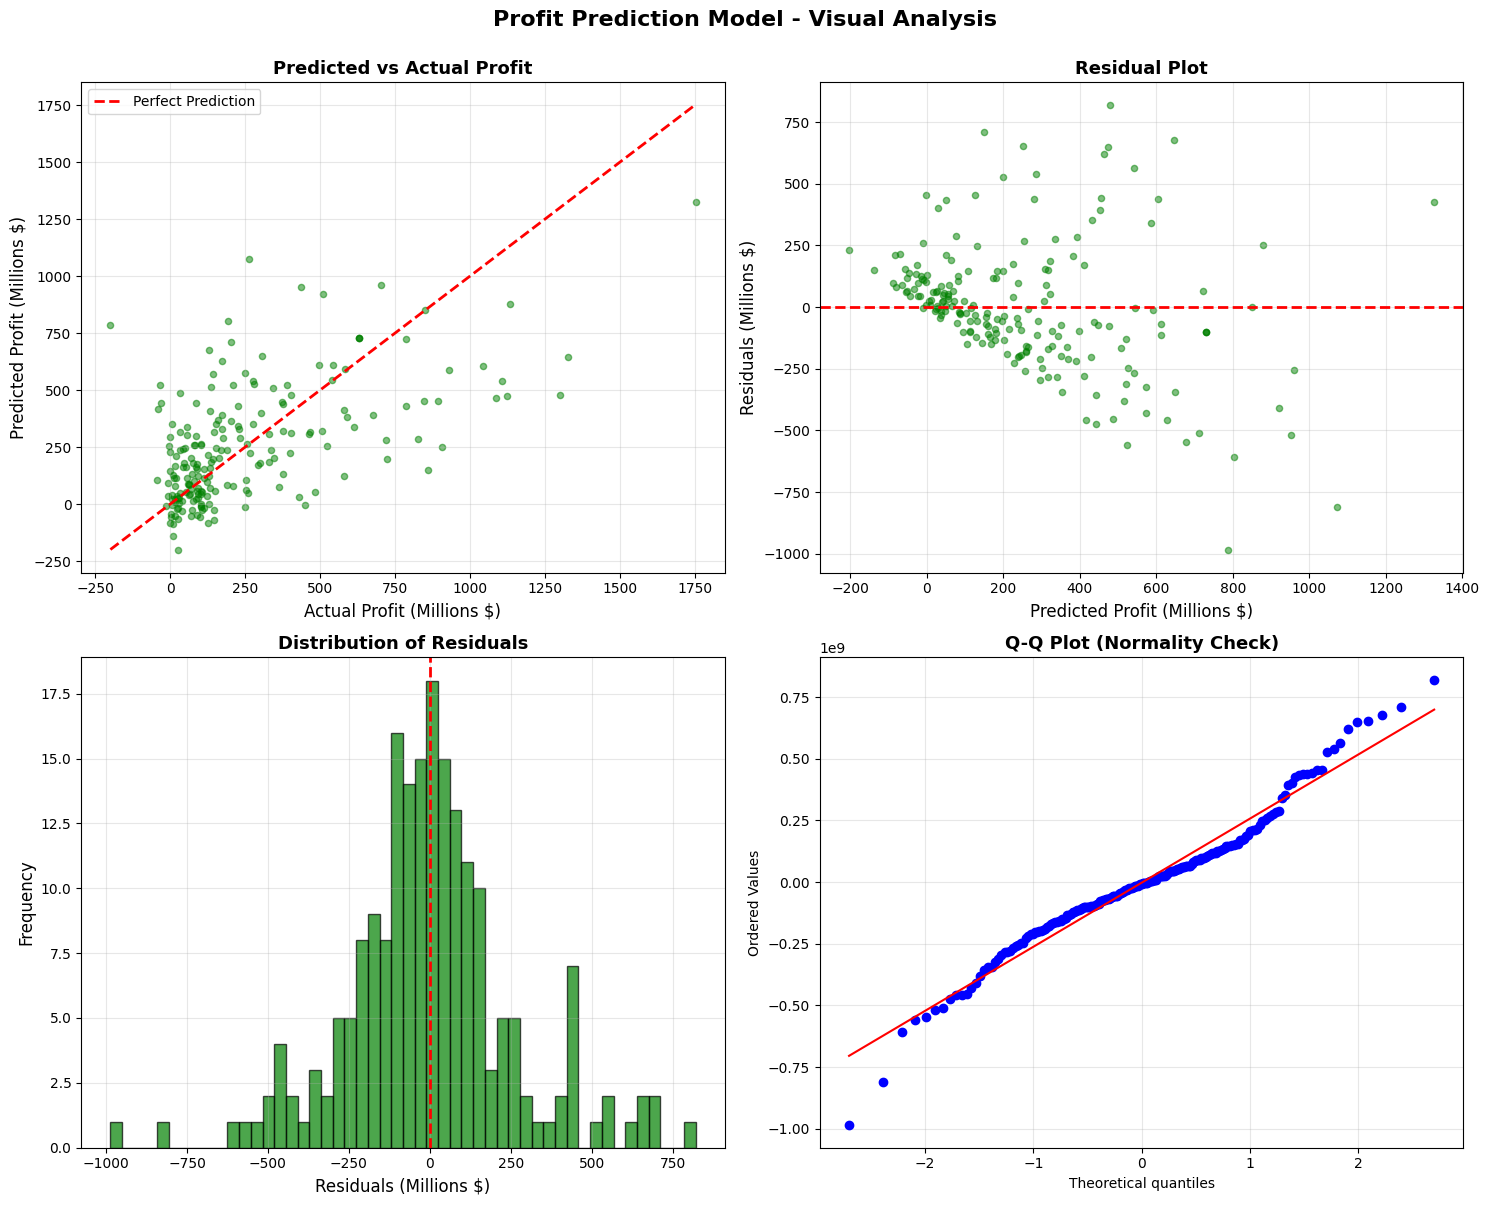

Profit Model Residual Statistics:
  Mean: $-2,581,977
  Std: $262,247,236
  Min: $-986,731,252
  Max: $820,940,791


In [24]:
# Profit Model Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Profit Prediction Model - Visual Analysis', fontsize=16, fontweight='bold', y=1.00)

# 1. Predicted vs Actual (Test Set)
axes[0, 0].scatter(y_profit_test / 1e6, y_profit_test_pred / 1e6, alpha=0.5, s=20, color='green')
axes[0, 0].plot([y_profit_test.min() / 1e6, y_profit_test.max() / 1e6], 
                [y_profit_test.min() / 1e6, y_profit_test.max() / 1e6], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Profit (Millions $)', fontsize=12)
axes[0, 0].set_ylabel('Predicted Profit (Millions $)', fontsize=12)
axes[0, 0].set_title('Predicted vs Actual Profit', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residual Plot
residuals_profit = y_profit_test - y_profit_test_pred
axes[0, 1].scatter(y_profit_test_pred / 1e6, residuals_profit / 1e6, alpha=0.5, s=20, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Profit (Millions $)', fontsize=12)
axes[0, 1].set_ylabel('Residuals (Millions $)', fontsize=12)
axes[0, 1].set_title('Residual Plot', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of Residuals
axes[1, 0].hist(residuals_profit / 1e6, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuals (Millions $)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of Residuals', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q Plot
stats.probplot(residuals_profit, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Profit Model Residual Statistics:")
print(f"  Mean: ${residuals_profit.mean():,.0f}")
print(f"  Std: ${residuals_profit.std():,.0f}")
print(f"  Min: ${residuals_profit.min():,.0f}")
print(f"  Max: ${residuals_profit.max():,.0f}")

## 8. Feature Importance Analysis

In [25]:
# Profit Model Feature Importance
profit_feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': profit_model.coef_
})

profit_feature_importance['abs_coefficient'] = profit_feature_importance['coefficient'].abs()
profit_feature_importance = profit_feature_importance.sort_values('abs_coefficient', ascending=False)

print("="*80)
print("PROFIT MODEL - Top 20 Most Important Features:")
print("="*80)
for idx, row in profit_feature_importance.head(20).iterrows():
    direction = "↑" if row['coefficient'] > 0 else "↓"
    print(f"{row['feature']:50s} {direction} ${row['coefficient']:15,.0f}")

print(f"\nProfit Model Intercept: ${profit_model.intercept_:,.0f}")

PROFIT MODEL - Top 20 Most Important Features:
director_nm0000116                                 ↑ $    773,467,226
director_nm1349376                                 ↑ $    324,050,695
director_nm0796117                                 ↑ $    313,242,592
director_nm0001466                                 ↓ $   -282,125,375
actor_nm0695435                                    ↑ $    281,262,391
company_Lucasfilm_Ltd                              ↑ $    276,688,310
director_nm0001060                                 ↑ $    270,179,856
director_nm0000217                                 ↓ $   -245,785,380
director_nm0680846                                 ↑ $    243,475,398
director_nm0751648                                 ↑ $    224,598,197
director_nm0751577                                 ↑ $    224,598,197
company_Amblin_Entertainment                       ↑ $    222,134,718
company_Marvel_Studios                             ↑ $    220,388,997
lang_zh                                    

In [26]:
# Analyze Director and Actor Impact
print("="*80)
print("DIRECTOR & ACTOR IMPACT ANALYSIS")
print("="*80)

# Load IMDb name data to get actual names
print("Loading IMDb name data...")
import gzip
name_data = pd.read_csv('../data/raw/name.basics.tsv.gz', 
                        sep='\t', 
                        usecols=['nconst', 'primaryName'],
                        compression='gzip')
print(f"Loaded {len(name_data):,} names from IMDb")

# Create ID to name mapping
id_to_name = dict(zip(name_data['nconst'], name_data['primaryName']))
print(f"Created mapping for {len(id_to_name):,} people")

# Get director features from profit model (filter out zero coefficients)
director_importance_profit = profit_feature_importance[
    profit_feature_importance['feature'].str.startswith('director_')
].copy()

director_importance_profit_nonzero = director_importance_profit[
    director_importance_profit['coefficient'] != 0
].sort_values('abs_coefficient', ascending=False)

print(f"\nDirectors with NON-ZERO coefficients: {len(director_importance_profit_nonzero)} out of {len(director_importance_profit)}")

if len(director_importance_profit_nonzero) > 0:
    print("\nTop Directors by Impact:")
    for idx, row in director_importance_profit_nonzero.head(15).iterrows():
        imdb_id = row['feature'].replace('director_', '')
        director_name = id_to_name.get(imdb_id, f"Unknown ({imdb_id})")
        direction = "↑" if row['coefficient'] > 0 else "↓"
        print(f"  {director_name:40s} {direction} ${row['coefficient']:15,.0f}")
else:
    print("⚠️  No directors with non-zero coefficients!")

# Get actor features from profit model (filter out zero coefficients)
actor_importance_profit = profit_feature_importance[
    profit_feature_importance['feature'].str.startswith('actor_')
].copy()

actor_importance_profit_nonzero = actor_importance_profit[
    actor_importance_profit['coefficient'] != 0
].sort_values('abs_coefficient', ascending=False)

print(f"\nActors with NON-ZERO coefficients: {len(actor_importance_profit_nonzero)} out of {len(actor_importance_profit)}")

if len(actor_importance_profit_nonzero) > 0:
    print("\nTop Actors by Impact:")
    for idx, row in actor_importance_profit_nonzero.head(15).iterrows():
        imdb_id = row['feature'].replace('actor_', '')
        actor_name = id_to_name.get(imdb_id, f"Unknown ({imdb_id})")
        direction = "↑" if row['coefficient'] > 0 else "↓"
        print(f"  {actor_name:40s} {direction} ${row['coefficient']:15,.0f}")
else:
    print("⚠️  No actors with non-zero coefficients!")

DIRECTOR & ACTOR IMPACT ANALYSIS
Loading IMDb name data...
Loaded 14,745,597 names from IMDb
Created mapping for 14,745,597 people

Directors with NON-ZERO coefficients: 50 out of 50

Top Directors by Impact:
  James Cameron                            ↑ $    773,467,226
  Francis Lawrence                         ↑ $    324,050,695
  M. Night Shyamalan                       ↑ $    313,242,592
  Sergio Leone                             ↓ $   -282,125,375
  Chris Columbus                           ↑ $    270,179,856
  Martin Scorsese                          ↓ $   -245,785,380
  Todd Phillips                            ↑ $    243,475,398
  Joe Russo                                ↑ $    224,598,197
  Anthony Russo                            ↑ $    224,598,197
  David Yates                              ↑ $    200,563,055
  James Wan                                ↑ $    191,383,635
  Sam Mendes                               ↑ $    179,276,905
  Jon Favreau                              ↑ $ 

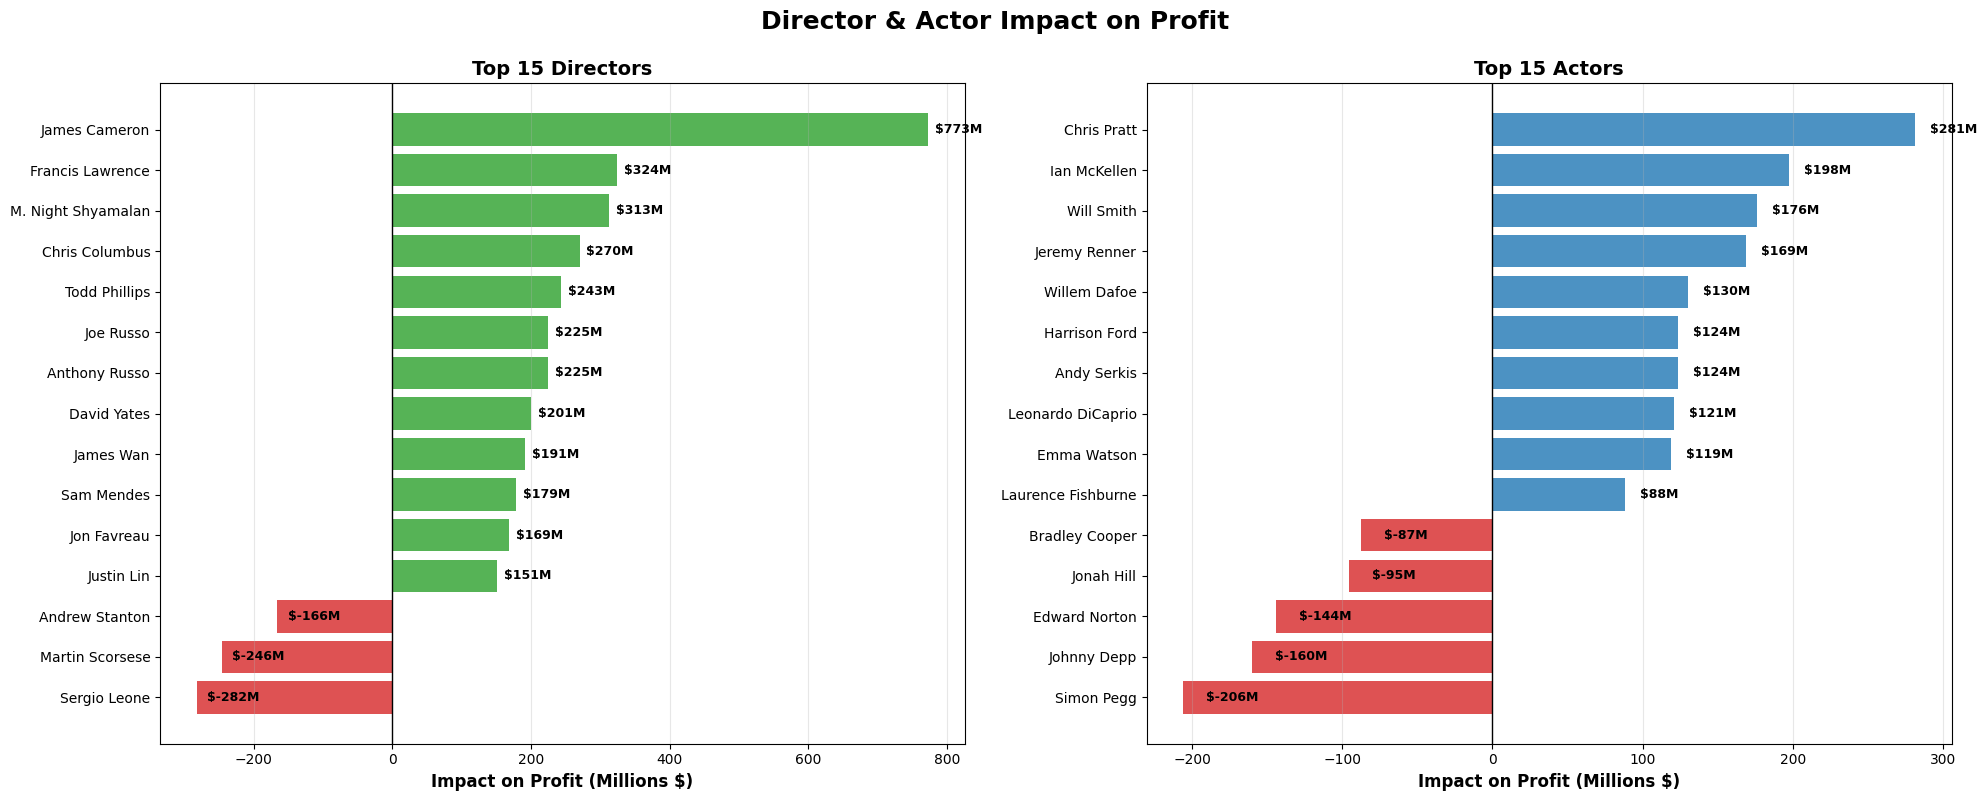


VISUALIZATION SUMMARY
✓ Green bars = Positive impact (increases profit)
✓ Red bars = Negative impact (decreases profit)

Top positive director: James Cameron (+$773M)
Top negative director: Sergio Leone ($-282M)
Top positive actor: Chris Pratt (+$281M)
Top negative actor: Simon Pegg ($-206M)


In [27]:
# Visualize Director and Actor Impact
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Director & Actor Impact on Profit', fontsize=18, fontweight='bold', y=0.995)

# Prepare data for visualization - Top 15 directors and actors
top_n = 15

# Profit Model - Directors
director_prof_vis = director_importance_profit_nonzero.head(top_n).copy()
director_prof_vis['name'] = director_prof_vis['feature'].apply(
    lambda x: id_to_name.get(x.replace('director_', ''), 'Unknown')
)
director_prof_vis = director_prof_vis.sort_values('coefficient')

colors_dir_prof = ['#d62728' if x < 0 else '#2ca02c' for x in director_prof_vis['coefficient']]
axes[0].barh(director_prof_vis['name'], director_prof_vis['coefficient'] / 1e6, color=colors_dir_prof, alpha=0.8)
axes[0].set_xlabel('Impact on Profit (Millions $)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Top {top_n} Directors', fontsize=14, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0].grid(True, alpha=0.3, axis='x')
for i, (idx, row) in enumerate(director_prof_vis.iterrows()):
    value = row['coefficient'] / 1e6
    if value > 0:
        x_pos = value + 10
        ha = 'left'
    else:
        # For negative values, place label inside the bar near the end
        x_pos = value + 15
        ha = 'left'
    axes[0].text(x_pos, i, f'${value:,.0f}M', va='center', ha=ha, fontsize=9, fontweight='bold')

# Profit Model - Actors
actor_prof_vis = actor_importance_profit_nonzero.head(top_n).copy()
actor_prof_vis['name'] = actor_prof_vis['feature'].apply(
    lambda x: id_to_name.get(x.replace('actor_', ''), 'Unknown')
)
actor_prof_vis = actor_prof_vis.sort_values('coefficient')

colors_act_prof = ['#d62728' if x < 0 else '#1f77b4' for x in actor_prof_vis['coefficient']]
axes[1].barh(actor_prof_vis['name'], actor_prof_vis['coefficient'] / 1e6, color=colors_act_prof, alpha=0.8)
axes[1].set_xlabel('Impact on Profit (Millions $)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Top {top_n} Actors', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1].grid(True, alpha=0.3, axis='x')
for i, (idx, row) in enumerate(actor_prof_vis.iterrows()):
    value = row['coefficient'] / 1e6
    if value > 0:
        x_pos = value + 10
        ha = 'left'
    else:
        # For negative values, place label inside the bar near the end
        x_pos = value + 15
        ha = 'left'
    axes[1].text(x_pos, i, f'${value:,.0f}M', va='center', ha=ha, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("VISUALIZATION SUMMARY")
print("="*80)
print("✓ Green bars = Positive impact (increases profit)")
print("✓ Red bars = Negative impact (decreases profit)")
print(f"\nTop positive director: {director_prof_vis.iloc[-1]['name']} (+${director_prof_vis.iloc[-1]['coefficient']/1e6:,.0f}M)")
print(f"Top negative director: {director_prof_vis.iloc[0]['name']} (${director_prof_vis.iloc[0]['coefficient']/1e6:,.0f}M)")
print(f"Top positive actor: {actor_prof_vis.iloc[-1]['name']} (+${actor_prof_vis.iloc[-1]['coefficient']/1e6:,.0f}M)")
print(f"Top negative actor: {actor_prof_vis.iloc[0]['name']} (${actor_prof_vis.iloc[0]['coefficient']/1e6:,.0f}M)")

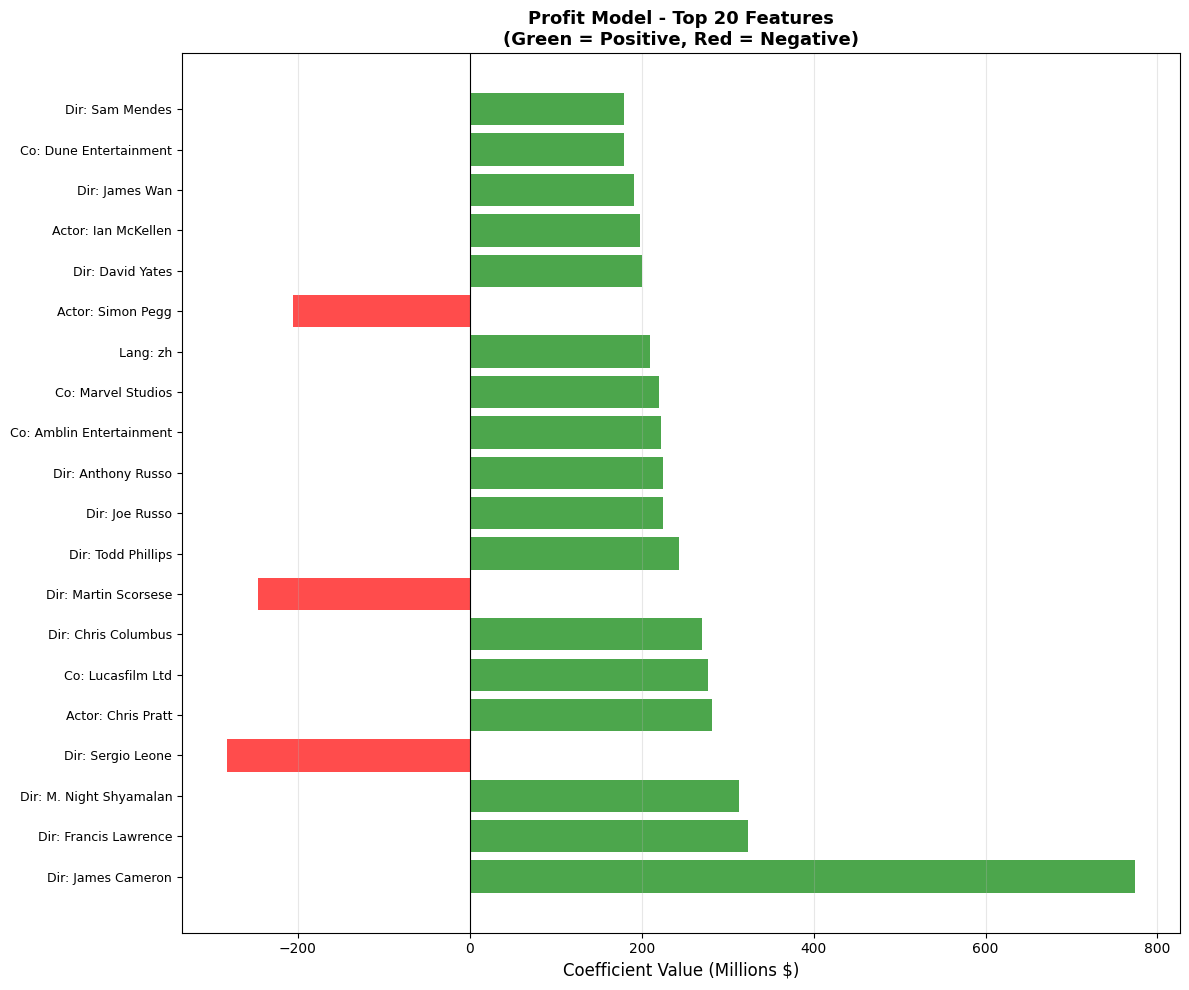

In [28]:
# Visualize top features for profit model
fig = plt.figure(figsize=(12, 10))

# Function to convert feature names to readable format
def format_feature_name(feature):
    if feature.startswith('director_nm'):
        imdb_id = feature.replace('director_', '')
        return f"Dir: {id_to_name.get(imdb_id, imdb_id)}"
    elif feature.startswith('actor_nm'):
        imdb_id = feature.replace('actor_', '')
        return f"Actor: {id_to_name.get(imdb_id, imdb_id)}"
    elif feature.startswith('company_'):
        return feature.replace('company_', 'Co: ').replace('_', ' ')
    elif feature.startswith('genre_'):
        return feature.replace('genre_', 'Genre: ')
    elif feature.startswith('country_'):
        return feature.replace('country_', 'Country: ')
    elif feature.startswith('lang_'):
        return feature.replace('lang_', 'Lang: ')
    else:
        return feature

# Profit model
top_profit = profit_feature_importance.head(20).copy()
top_profit['display_name'] = top_profit['feature'].apply(format_feature_name)
colors_profit = ['green' if x > 0 else 'red' for x in top_profit['coefficient']]
plt.barh(range(len(top_profit)), top_profit['coefficient'] / 1e6, color=colors_profit, alpha=0.7)
plt.yticks(range(len(top_profit)), top_profit['display_name'], fontsize=9)
plt.xlabel('Coefficient Value (Millions $)', fontsize=12)
plt.title('Profit Model - Top 20 Features\n(Green = Positive, Red = Negative)', 
          fontsize=13, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 9. Save Models

In [29]:
# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save Profit Model
profit_model_path = '../models/profit_prediction_model.pkl'
joblib.dump(profit_model, profit_model_path)
print(f"✓ Profit model saved to: {profit_model_path}")

✓ Profit model saved to: ../models/profit_prediction_model.pkl


In [30]:
# Save Profit Model Metadata
profit_metadata = {
    'model_type': 'LinearRegression',
    'target_variable': 'profit',
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': len(feature_columns),
    'feature_columns': feature_columns,
    'train_size': len(X_train),
    'test_size': len(X_test),
    'performance_metrics': {
        'train': {
            'rmse': float(profit_train_metrics['rmse']),
            'mae': float(profit_train_metrics['mae']),
            'r2': float(profit_train_metrics['r2']),
            'mape': float(profit_train_metrics['mape'])
        },
        'test': {
            'rmse': float(profit_test_metrics['rmse']),
            'mae': float(profit_test_metrics['mae']),
            'r2': float(profit_test_metrics['r2']),
            'mape': float(profit_test_metrics['mape'])
        }
    },
    'intercept': float(profit_model.intercept_),
    'top_10_features': profit_feature_importance.head(10)[['feature', 'coefficient']].to_dict('records')
}

profit_metadata_path = '../models/profit_prediction_metadata.json'
with open(profit_metadata_path, 'w') as f:
    json.dump(profit_metadata, f, indent=2)
print(f"✓ Profit model metadata saved to: {profit_metadata_path}")

✓ Profit model metadata saved to: ../models/profit_prediction_metadata.json


In [31]:
# Final Summary
print("\n" + "="*80)
print(" MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("="*80)

print("\n💰 PROFIT PREDICTION MODEL:")
print(f"  - Training samples: {len(X_train):,}")
print(f"  - Test samples: {len(X_test):,}")
print(f"  - Features: {len(feature_columns)}")
print(f"  - Test R² Score: {profit_test_metrics['r2']:.4f}")
print(f"  - Test RMSE: ${profit_test_metrics['rmse']:,.0f}")
print(f"  - Test MAE: ${profit_test_metrics['mae']:,.0f}")
print(f"  - Test MAPE: {profit_test_metrics['mape']:.2f}%")

print("\n📁 Saved Files:")
print(f"  - {profit_model_path}")
print(f"  - {profit_metadata_path}")

print("\n" + "="*80)


 MODEL TRAINING COMPLETED SUCCESSFULLY!

💰 PROFIT PREDICTION MODEL:
  - Training samples: 803
  - Test samples: 201
  - Features: 190
  - Test R² Score: 0.2613
  - Test RMSE: $261,606,808
  - Test MAE: $187,619,109
  - Test MAPE: 2312.73%

📁 Saved Files:
  - ../models/profit_prediction_model.pkl
  - ../models/profit_prediction_metadata.json

